# Nasdaq Analysis during War periods

In [108]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats


In [109]:
nasdaq = yf.download("^IXIC", period="50y")
nasdaq.columns = nasdaq.columns.get_level_values(0)
nasdaq = nasdaq.reset_index()
nasdaq

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,1976-05-17,89.489998,89.489998,89.489998,89.489998,0
1,1976-05-18,89.529999,89.529999,89.529999,89.529999,0
2,1976-05-19,89.250000,89.250000,89.250000,89.250000,0
3,1976-05-20,89.529999,89.529999,89.529999,89.529999,0
4,1976-05-21,89.389999,89.389999,89.389999,89.389999,0
...,...,...,...,...,...,...
12598,2026-05-08,26247.080078,26248.619141,25944.779297,25958.119141,9577150000
12599,2026-05-11,26274.130859,26359.310547,26129.830078,26135.630859,11989910000
12600,2026-05-12,26088.199219,26190.480469,25739.220703,26087.009766,9631840000
12601,2026-05-13,26402.339844,26474.179688,25990.160156,26147.650391,9734720000


In [110]:
nasdaq["daily_return"] = nasdaq["Close"].pct_change()*100
nasdaq.head()

Price,Date,Close,High,Low,Open,Volume,daily_return
0,1976-05-17,89.489998,89.489998,89.489998,89.489998,0,NaN
1,1976-05-18,89.529999,89.529999,89.529999,89.529999,0,0.044699
2,1976-05-19,89.250000,89.250000,89.250000,89.250000,0,-0.312743
3,1976-05-20,89.529999,89.529999,89.529999,89.529999,0,0.313724
4,1976-05-21,89.389999,89.389999,89.389999,89.389999,0,-0.156371


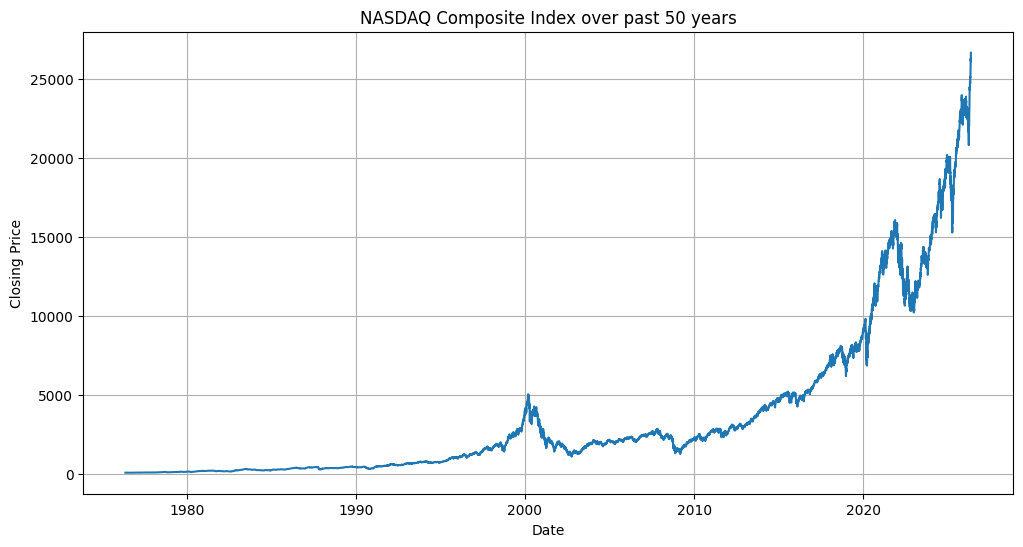

In [111]:
plt.figure(figsize=(12, 6))
plt.plot(nasdaq["Date"], nasdaq["Close"])
plt.title("NASDAQ Composite Index over past 50 years")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid()

## Gulf War

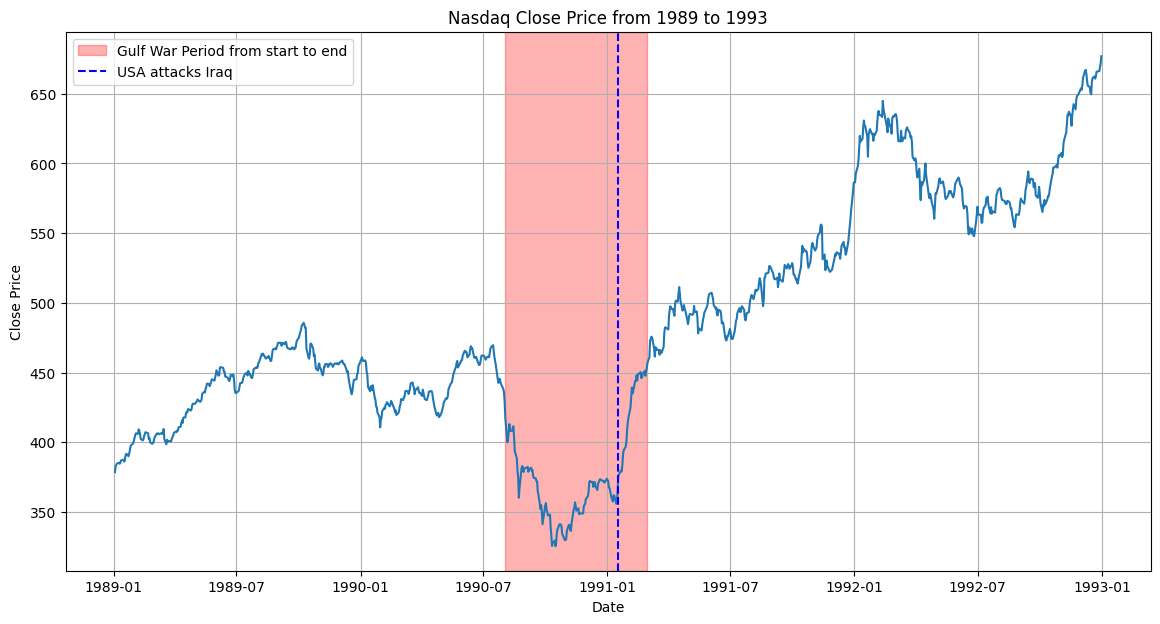

In [112]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "1989-01-01") & (nasdaq["Date"] <= "1993-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("1990-08-02", "1991-02-28", alpha=0.3, color="red", label="Gulf War Period from start to end")
plt.axvline(x = pd.to_datetime("1991-01-17"), color="blue", linestyle="--", label="USA attacks Iraq")
plt.legend()
plt.title("Nasdaq Close Price from 1989 to 1993")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

Gulf War Timeline

1990-08-02 — Iraq invades Kuwait
1990-08-07 — US deploys troops to Saudi Arabia (Operation Desert Shield)
1990-11-29 — UN issues ultimatum to Iraq: withdraw by 1991-01-15
1991-01-15 — UN deadline expires
1991-01-17 — US-led coalition launches air strikes on Iraq (Operation Desert Storm)
1991-02-24 — Ground offensive begins
1991-02-28 — Bush declares ceasefire, war ends

Analysis

The price of NASDAQ fell immediately after Iraq invades Kuwait. The reasons behind this include the rise of oil price, and uncertainty over whether and how the United States would intervene, and in the length it will continue.

The price of NASDAQ rose rapidly in 1991-01-17, when US-led coalition launched air strikes on Iraq. This event sparked optimism among investors, while also resolving uncertainties surrounding the war. 

In [113]:
avg_return = nasdaq["daily_return"].mean()
# The Gulf War occurred from August 2, 1990, to February 28, 1991. We will filter the data for this period and calculate the average return during the Gulf War.
gulf_war = nasdaq[(nasdaq["Date"] >= "1990-08-02") & (nasdaq["Date"] <= "1991-02-28")]
avg_gulf_return = gulf_war["daily_return"].mean()

print(f'The average return of Nasdaq of past 50 years is {avg_return :.2f}%')
print(f'The average return during Gulf War is {avg_gulf_return :.2f}%')

The average return of Nasdaq of past 50 years is 0.05%
The average return during Gulf War is 0.03%


In [114]:
# Perform a two tailed z-test to determine if the average return during the Gulf War is significantly different from the overall average return.
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_gulf_return
sample_size = len(gulf_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_gulf = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_gulf}')
print(f'At a significance level of 0.05, we {"reject" if p_value < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Gulf War compared to the overall average return.')

Standard Error: 0.10814799918807431
Z-score: -0.17546918053749266
P-value: 0.8607109854246022
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Gulf War compared to the overall average return.


## Iraq War

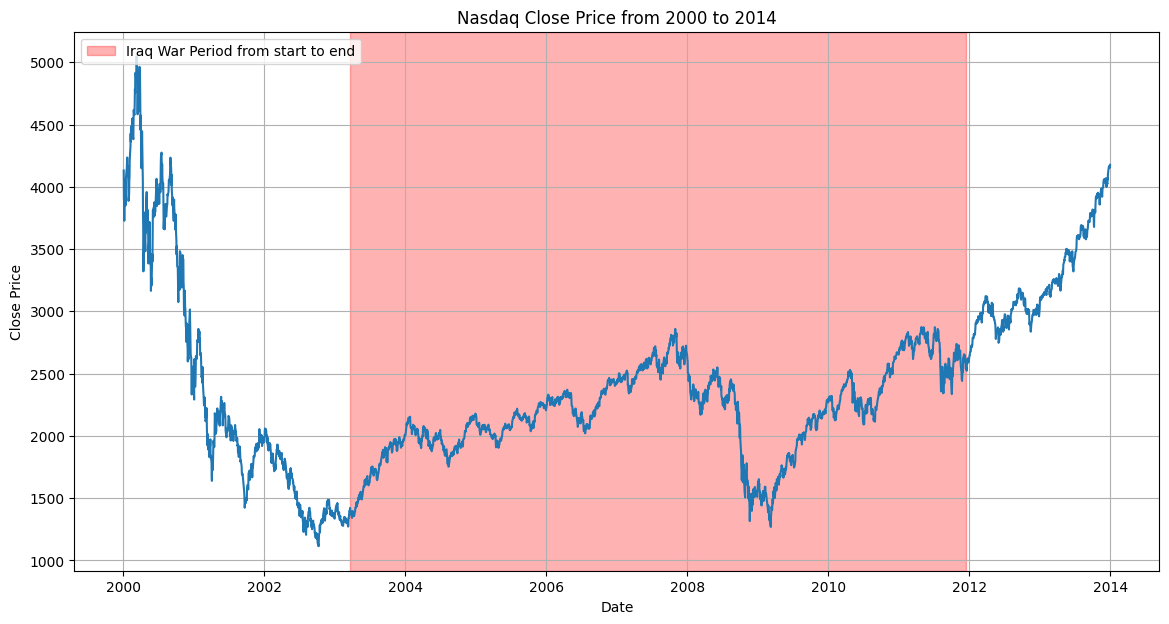

In [115]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2000-01-01") & (nasdaq["Date"] <= "2014-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("2003-03-20", "2011-12-15", alpha=0.3, color="red", label="Iraq War Period from start to end")
plt.title("Nasdaq Close Price from 2000 to 2014")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

Iraq War Timeline

2002-09-12 — Bush addresses UN, warns of Iraq threat
2002-10-16 — US Congress authorizes use of military force against Iraq
2003-02-05 — Colin Powell presents evidence of WMDs at UN
2003-03-17 — Bush issues 48-hour ultimatum to Saddam Hussein
2003-03-20 — US-led coalition invades Iraq
2003-04-09 — Baghdad falls, Saddam statue toppled
2003-05-01 — Bush declares "Mission Accomplished"
2008-09-15 — Lehman Brothers collapse (financial crisis begins)
2011-12-15 — US military formally withdraws from Iraq, war ends

Analysis

Even before the Iraq War was declared, the price of NASDAQ had already dropped approximately 75% from its previous peak, largely due to the collapse of the dot-com bubble, which heavily affected NASDAQ-listed tech stocks. On top of this, the impact of the war was already priced in by the market as early as September 2002, when Bush addressed the UN and warned of the Iraq threat, causing uncertainty to rise ahead of the official declaration.

Due to overlapping impact of dot-com bubble and Lehman Brothers crisis, isolating the impact of Iraq war on NASDAQ is difficult.

In [116]:
iraq_war = nasdaq[(nasdaq["Date"] >= "2003-03-20") & (nasdaq["Date"] <= "2011-12-15")]
avg_iraq_return = iraq_war["daily_return"].mean()
print (f"The average return of Nasdaq of past 50 years is {avg_return :.2f}%")
print(f"The average return during Iraq War is {avg_iraq_return :.2f}%")

The average return of Nasdaq of past 50 years is 0.05%
The average return during Iraq War is 0.04%


In [117]:
# Perform a two tailed z-test to determine if the average return during the Iraq War is significantly different from the overall average return.
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_iraq_return
sample_size = len(iraq_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_iraq = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_iraq}')
print(f'At a significance level of 0.05, we {"reject" if p_value < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Iraq War compared to the overall average return.')

Standard Error: 0.02783486516671808
Z-score: -0.5656670881826545
P-value: 0.5716201124124694
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Iraq War compared to the overall average return.


## War in Afghanistan

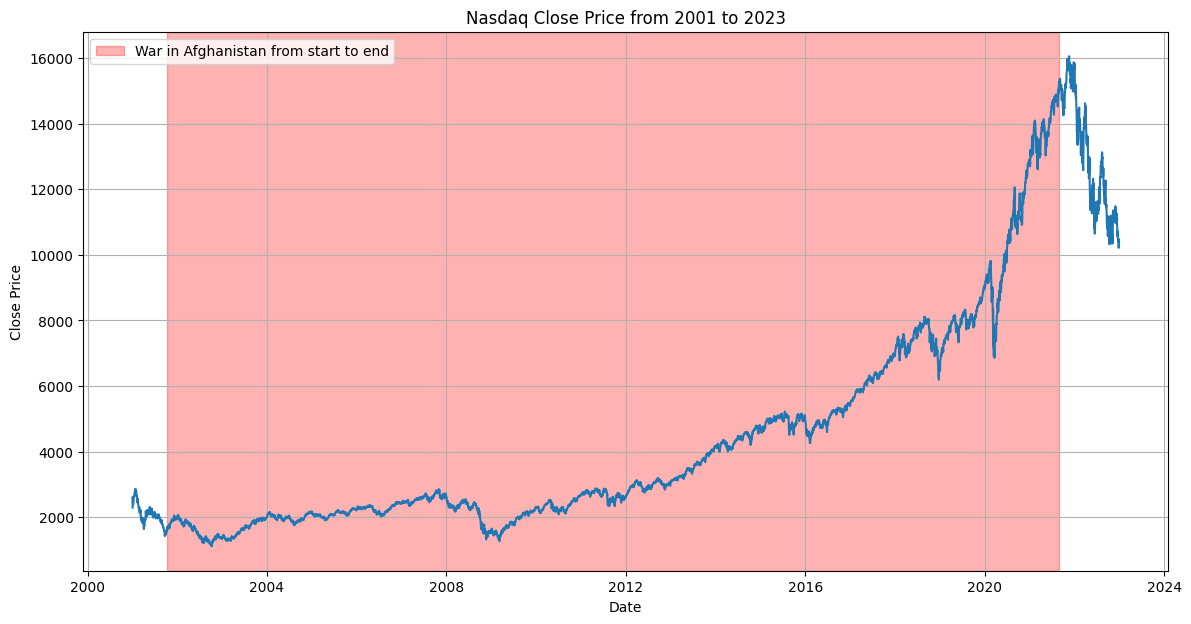

In [118]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2001-01-01" ) & (nasdaq["Date"] <= "2023-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("2001-10-07", "2021-08-30", alpha=0.3, color="red", label="War in Afghanistan from start to end")
plt.title("Nasdaq Close Price from 2001 to 2023")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

The period between the start and end of the war spanned around 20 years. This length of a term makes it difficult to visualize the impact of the war on NASDAQ as resolution of uncertainty affects relatively short length of time, and many different factors got envolved over such a long timeframe.

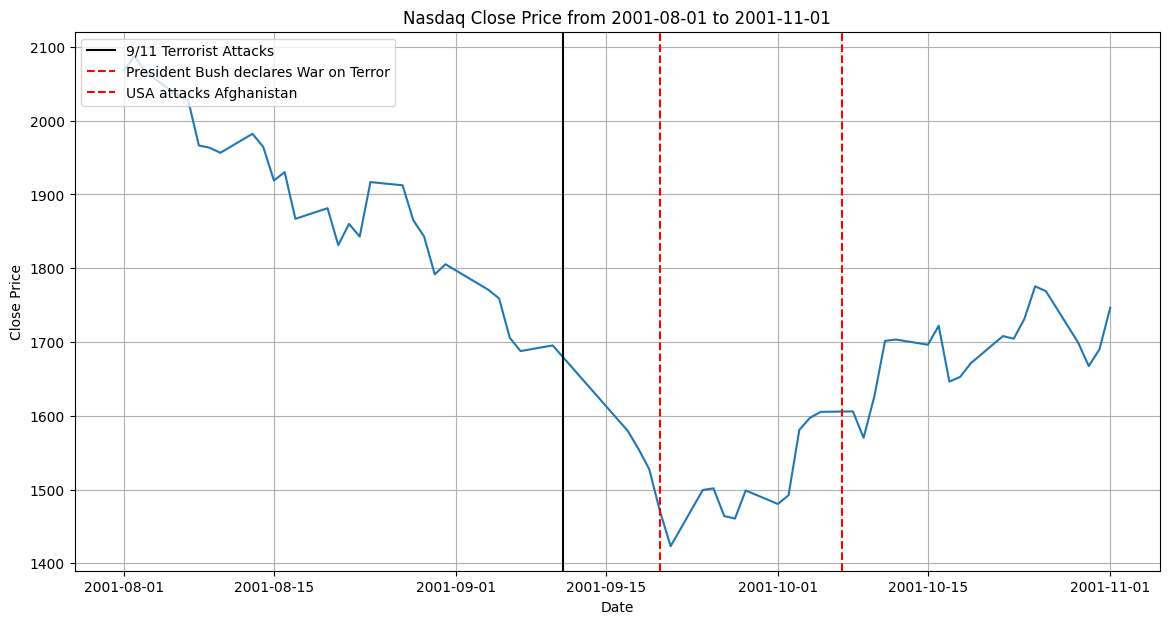

In [119]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2001-08-01") & (nasdaq["Date"] <= "2001-11-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvline(x = pd.to_datetime("2001-09-11"), color = "black" ,label="9/11 Terrorist Attacks")
plt.axvline(x = pd.to_datetime("2001-09-20"), color = "red", linestyle = "--", label="President Bush declares War on Terror")
plt.axvline(x = pd.to_datetime("2001-10-07"), color = "red", linestyle = "--", label="USA attacks Afghanistan")

plt.title("Nasdaq Close Price from 2001-08-01 to 2001-11-01")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

Afghanistan War Timeline

2001-09-11 — Al-Qaeda terrorist attacks on US soil (9/11)
2001-09-20 — Bush declares War on Terror, issues ultimatum to Taliban
2001-10-07 — US-led coalition invades Afghanistan (Operation Enduring Freedom)
2001-11-13 — Taliban regime falls, Kabul captured
2009-02-17 — Obama approves troop surge
2011-05-02 — Osama bin Laden killed in Pakistan
2014-12-28 — US formally ends combat mission
2021-08-15 — Taliban retakes Kabul
2021-08-30 — US completes full military withdrawal, war ends

Analysis

In 2001-09-11, 9/11 Terror attack occured. This incident made NASDAQ to fall rapidly, and escalated uncertainties for investors. 

After president Bush declared War on Terror in 2001-09-20, the uncertainty was highly resolved, and when US attacked Afghanistan in 2001-10-07, the uncertainty caused by the war was mostly resolved.


In [120]:
# 
afghan_war = nasdaq[(nasdaq["Date"] >= "2001-09-20") & (nasdaq["Date"] <= "2021-08-30")]
avg_afghan_return = afghan_war["daily_return"].mean()
print (f"The average return of Nasdaq of past 50 years is {avg_return :.2f}%")
print(f"The average return during Russia-Ukraine War is {avg_afghan_return :.2f}%")

The average return of Nasdaq of past 50 years is 0.05%
The average return during Russia-Ukraine War is 0.06%


In [121]:
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_afghan_return
sample_size = len(afghan_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_afghan = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_afghan}')
print(f'At a significance level of 0.05, we {"reject" if p_value < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Afghanistan War compared to the overall average return.')

Standard Error: 0.018441651313143067
Z-score: 0.10375143596328322
P-value: 0.9173666068772763
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Afghanistan War compared to the overall average return.


## Russia-Ukraine War (Ongoing)

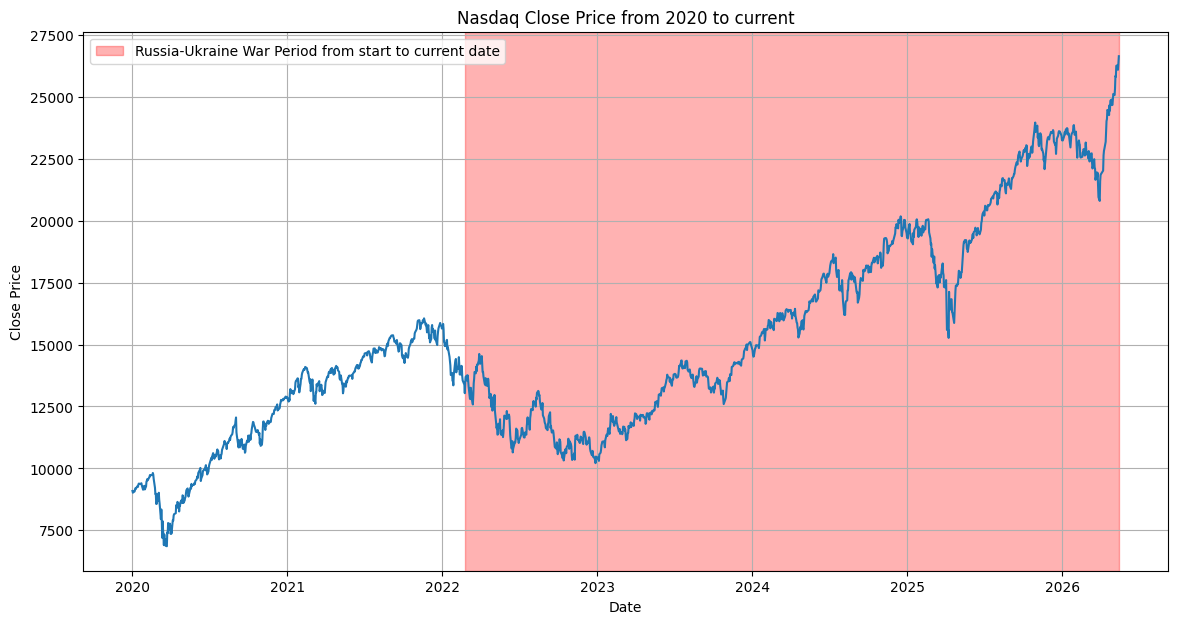

In [122]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2020-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("2022-02-24", nasdaq["Date"].max(), alpha=0.3, color="red", label="Russia-Ukraine War Period from start to current date")
plt.title("Nasdaq Close Price from 2020 to current")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

Russia-Ukraine War Timeline

2022-02-24 — Russia launches full-scale invasion of Ukraine
2022-02-26 — Russia removed from SWIFT international banking system
2022-03-08 — US bans Russian oil imports
2022-09-06 — Ukraine launches Kharkiv counteroffensive, recaptures significant territory
2023-06-04 — Ukraine launches major counteroffensive (largely unsuccessful)
2024-11-05 — Trump re-elected, raising hopes for ceasefire negotiations
2025-03 — US-brokered ceasefire talks begin

Analysis

After the invasion in 2022-02-24, NASDAQ reacted immediately downward. As war continued for a long period of time, the market became stable and moved onto an ignoring phase. The point where uncertainty became fully resolved is unclear as the war is still ongoing.


In [123]:
# The Russia-Ukraine War started on February 24, 2022, and is ongoing. We will filter the data from this date to the current date and calculate the average return during this period.
rus_war = nasdaq[(nasdaq["Date"] >= "2022-02-24")]
avg_rus_return = rus_war["daily_return"].mean()
print (f"The average return of Nasdaq of past 50 years is {avg_return :.2f}%")
print(f"The average return during Russia-Ukraine War is {avg_rus_return :.2f}%")

The average return of Nasdaq of past 50 years is 0.05%
The average return during Russia-Ukraine War is 0.08%


In [124]:
# Perform a two tailed z-test to determine if the average return during the Russia-Ukraine War is significantly different from the overall average return.
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_rus_return
sample_size = len(rus_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_rus = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_rus}')
print(f'At a significance level of 0.05, we {"reject" if p_value < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Russia-Ukraine War compared to the overall average return.')

Standard Error: 0.04015567558543128
Z-score: 0.6032212361379279
P-value: 0.5463615222012543
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Russia-Ukraine War compared to the overall average return.


# Results

In [129]:
print(
    f'The p-value for the Gulf War is {p_value_gulf:.4f},\n'
    f'for the Iraq War is {p_value_iraq:.4f},\n'
    f'for the Afghanistan War is {p_value_afghan:.4f},\n'
    f'and for the Russia-Ukraine War is {p_value_rus:.4f}. \n\n'
    f'The significance level of 0.05 is used to determine whether to reject the null hypothesis of no difference in returns during each war compared to the overall average return.'
)

The p-value for the Gulf War is 0.8607,
for the Iraq War is 0.5716,
for the Afghanistan War is 0.9174,
and for the Russia-Ukraine War is 0.5464. 

The significance level of 0.05 is used to determine whether to reject the null hypothesis of no difference in returns during each war compared to the overall average return.


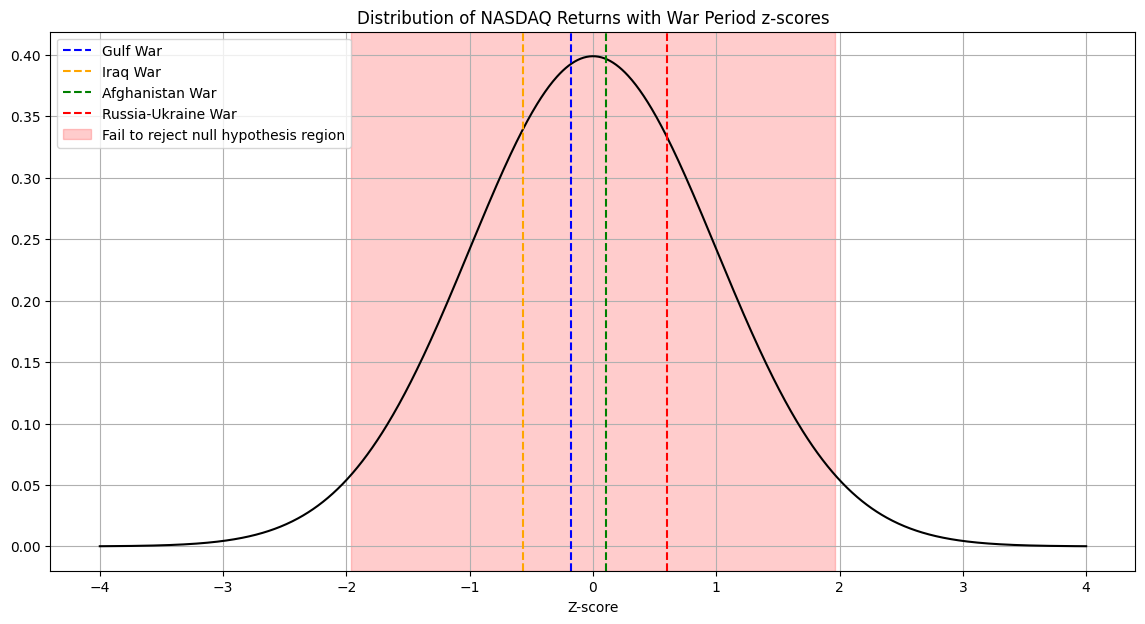

In [149]:
import numpy as np

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(14, 7))
plt.plot(x, y, color="black")

plt.axvline(x=-0.1755, color="blue", linestyle = "--",label=f"Gulf War")
plt.axvline(x=-0.5657, color="orange", linestyle = "--",label=f"Iraq War")
plt.axvline(x=0.1038, color="green", linestyle = "--",label=f"Afghanistan War")
plt.axvline(x=0.6032, color="red", linestyle = "--",label=f"Russia-Ukraine War")

plt.axvspan(-1.96, 1.96, alpha=0.2, color="red", label="Fail to reject null hypothesis region")

plt.title("Distribution of NASDAQ Returns with War Period z-scores")
plt.xlabel("Z-score")
plt.legend(loc = "upper left")
plt.grid()
plt.show()
